In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("rides_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   services        50000 non-null  object 
 1   date            50000 non-null  object 
 2   time            50000 non-null  object 
 3   ride_status     50000 non-null  object 
 4   source          50000 non-null  object 
 5   destination     50000 non-null  object 
 6   duration        50000 non-null  int64  
 7   ride_id         50000 non-null  object 
 8   distance        50000 non-null  float64
 9   ride_charge     44964 non-null  float64
 10  misc_charge     44964 non-null  float64
 11  total_fare      44964 non-null  float64
 12  payment_method  44964 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 5.0+ MB


In [4]:
df.describe().round(2)

,duration,distance,ride_charge,misc_charge,total_fare
count,50000.00,50000.00,44964.00,44964.00,44964.00
mean,64.32,25.53,522.43,24.96,547.39
std,31.85,14.18,274.73,14.46,275.09
min,10.00,1.00,50.03,0.00,50.58
25%,37.00,13.26,283.66,12.40,308.92
50%,64.00,25.46,520.03,25.07,544.92
75%,92.00,37.86,759.37,37.51,785.50
max,119.00,50.00,999.96,50.00,1048.80


In [5]:
df.isnull().sum()

services             0
date                 0
time                 0
ride_status          0
source               0
destination          0
duration             0
ride_id              0
distance             0
ride_charge       5036
misc_charge       5036
total_fare        5036
payment_method    5036
dtype: int64

In [6]:
df.shape

(50000, 13)

In [7]:
df[df.duplicated()].shape

(0, 13)

In [8]:
df['ride_id'].value_counts().head(10)

ride_id
RD3094937631331884    1
RD3161218751875354    1
RD8171514284594096    1
RD9376481122237926    1
RD3676889143182765    1
RD6639410275948084    1
RD5922205486441934    1
RD9557099396888459    1
RD9473873953525644    1
RD1285566012167240    1
Name: count, dtype: int64

In [9]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('_'*50)

services
bike           15128
auto           12327
cab economy    10202
parcel          7459
bike lite       4884
Name: count, dtype: int64
__________________________________________________
ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64
__________________________________________________
payment_method
Paytm         11315
GPay          11268
Amazon Pay    11225
QR scan       11156
Name: count, dtype: int64
__________________________________________________


In [23]:
df['ride_charge'].unique().tolist()

[764.83,
 314.83,
 nan,
 484.73,
 663.5,
 456.73,
 836.39,
 724.76,
 641.55,
 571.5,
 356.07,
 920.85,
 595.8,
 256.39,
 62.83,
 811.27,
 188.04,
 473.87,
 617.35,
 306.79,
 853.42,
 907.37,
 131.29,
 70.55,
 221.09,
 707.21,
 484.33,
 731.36,
 668.25,
 164.02,
 811.76,
 399.65,
 959.99,
 105.99,
 221.95,
 177.7,
 808.37,
 485.28,
 421.35,
 449.51,
 82.59,
 184.47,
 387.96,
 314.92,
 448.98,
 691.02,
 419.65,
 381.23,
 195.8,
 147.64,
 925.96,
 476.62,
 954.78,
 740.82,
 708.14,
 611.42,
 475.93,
 726.12,
 70.97,
 225.49,
 684.15,
 287.47,
 513.31,
 64.05,
 812.5,
 467.52,
 508.45,
 74.28,
 228.22,
 315.6,
 688.92,
 588.81,
 366.99,
 387.43,
 978.8,
 765.39,
 256.86,
 428.74,
 94.02,
 294.61,
 249.72,
 96.32,
 784.6,
 895.08,
 617.49,
 497.55,
 544.4,
 648.78,
 493.68,
 889.61,
 749.29,
 971.08,
 113.62,
 810.85,
 985.22,
 891.99,
 553.2,
 228.76,
 400.79,
 591.79,
 791.64,
 982.46,
 978.55,
 896.52,
 271.08,
 516.7,
 792.59,
 590.78,
 55.86,
 616.02,
 915.16,
 648.91,
 495.54,
 330.12

In [27]:
df_ride_charge = df[df['ride_charge'] != 'nan']['ride_charge']

In [28]:
ride_charge_median = int(df_ride_charge.dropna().astype('int64').median())

In [29]:
ride_charge_median

520

In [38]:
df['ride_charge'] = df['ride_charge'].fillna(ride_charge_median)

In [39]:
df['ride_charge'].unique().tolist()

[764.83,
 314.83,
 520.0,
 484.73,
 663.5,
 456.73,
 836.39,
 724.76,
 641.55,
 571.5,
 356.07,
 920.85,
 595.8,
 256.39,
 62.83,
 811.27,
 188.04,
 473.87,
 617.35,
 306.79,
 853.42,
 907.37,
 131.29,
 70.55,
 221.09,
 707.21,
 484.33,
 731.36,
 668.25,
 164.02,
 811.76,
 399.65,
 959.99,
 105.99,
 221.95,
 177.7,
 808.37,
 485.28,
 421.35,
 449.51,
 82.59,
 184.47,
 387.96,
 314.92,
 448.98,
 691.02,
 419.65,
 381.23,
 195.8,
 147.64,
 925.96,
 476.62,
 954.78,
 740.82,
 708.14,
 611.42,
 475.93,
 726.12,
 70.97,
 225.49,
 684.15,
 287.47,
 513.31,
 64.05,
 812.5,
 467.52,
 508.45,
 74.28,
 228.22,
 315.6,
 688.92,
 588.81,
 366.99,
 387.43,
 978.8,
 765.39,
 256.86,
 428.74,
 94.02,
 294.61,
 249.72,
 96.32,
 784.6,
 895.08,
 617.49,
 497.55,
 544.4,
 648.78,
 493.68,
 889.61,
 749.29,
 971.08,
 113.62,
 810.85,
 985.22,
 891.99,
 553.2,
 228.76,
 400.79,
 591.79,
 791.64,
 982.46,
 978.55,
 896.52,
 271.08,
 516.7,
 792.59,
 590.78,
 55.86,
 616.02,
 915.16,
 648.91,
 495.54,
 330.

In [42]:
df['ride_charge'].isnull().sum()

np.int64(0)

In [41]:
df['misc_charge'].unique().tolist()

[31.51,
 49.52,
 nan,
 15.84,
 14.13,
 25.19,
 14.95,
 31.34,
 21.48,
 47.63,
 33.18,
 44.03,
 23.72,
 31.98,
 23.51,
 41.32,
 46.52,
 13.24,
 33.34,
 44.68,
 39.57,
 20.55,
 29.98,
 45.91,
 27.5,
 1.91,
 34.22,
 39.42,
 15.86,
 20.01,
 14.11,
 49.05,
 7.62,
 4.11,
 21.74,
 38.45,
 22.93,
 9.32,
 38.34,
 17.19,
 37.1,
 31.56,
 34.13,
 17.6,
 38.46,
 28.65,
 37.16,
 47.65,
 6.89,
 24.65,
 31.0,
 7.8,
 36.66,
 28.07,
 44.5,
 24.19,
 14.45,
 11.37,
 48.15,
 4.68,
 19.18,
 30.82,
 11.66,
 43.41,
 35.62,
 3.14,
 22.24,
 44.69,
 48.06,
 42.39,
 16.95,
 10.77,
 17.58,
 48.62,
 17.83,
 28.02,
 25.15,
 17.3,
 33.83,
 30.79,
 28.31,
 17.15,
 46.95,
 49.5,
 30.74,
 36.56,
 17.8,
 15.37,
 11.15,
 28.73,
 37.42,
 19.27,
 20.72,
 15.09,
 40.4,
 25.11,
 40.94,
 34.81,
 17.53,
 14.33,
 35.17,
 31.5,
 27.65,
 41.97,
 21.19,
 34.82,
 25.26,
 25.99,
 7.88,
 30.98,
 2.36,
 11.48,
 39.71,
 20.71,
 23.83,
 10.69,
 24.29,
 7.92,
 10.72,
 17.82,
 33.67,
 6.23,
 2.98,
 18.5,
 4.44,
 20.43,
 32.15,
 29.72,
 22.

In [44]:
df['misc_charge'] = df['misc_charge'].fillna(df['misc_charge'].median())

In [45]:
df['misc_charge'].isnull().sum()

np.int64(0)

In [ ]:
df['misc_charge'] = df['misc_charge'].fillna(df['misc_charge'].median())

In [50]:
df['total_fare'].unique().tolist()

[796.34,
 364.35,
 nan,
 500.57,
 677.63,
 481.92,
 851.34,
 756.1,
 663.03,
 619.13,
 389.25,
 964.88,
 619.52,
 288.37,
 86.34,
 852.59,
 234.56,
 487.11,
 650.69,
 351.47,
 892.99,
 927.92,
 161.26999999999998,
 116.46,
 248.59,
 709.12,
 518.55,
 770.78,
 684.11,
 184.03,
 825.87,
 448.7,
 967.61,
 110.1,
 243.69,
 216.15,
 831.3,
 494.6,
 459.69000000000005,
 466.7,
 119.69,
 216.03,
 422.09,
 332.52000000000004,
 487.44,
 719.67,
 456.81,
 428.88,
 202.69,
 172.29,
 956.96,
 484.42,
 991.44,
 768.8900000000001,
 752.64,
 635.61,
 490.38,
 737.49,
 119.12,
 230.17,
 703.3299999999999,
 318.29,
 524.9699999999999,
 107.46,
 848.12,
 470.66,
 530.6899999999999,
 118.97,
 276.28,
 357.99,
 705.87,
 599.5799999999999,
 384.57,
 436.05,
 996.63,
 793.41,
 282.01,
 446.04,
 127.85,
 325.40000000000003,
 278.03,
 113.47,
 831.5500000000001,
 944.58,
 648.23,
 534.11,
 562.1999999999999,
 664.15,
 504.83,
 918.34,
 786.7099999999999,
 990.35,
 134.34,
 825.94,
 1025.62,
 917.1,
 594.14000

In [51]:
df['total_fare'] = (df['ride_charge'] + df['misc_charge']).round(2)

In [52]:
df['total_fare'].unique().tolist()

[796.34,
 364.35,
 545.07,
 500.57,
 677.63,
 481.92,
 851.34,
 756.1,
 663.03,
 619.13,
 389.25,
 964.88,
 619.52,
 288.37,
 86.34,
 852.59,
 234.56,
 487.11,
 650.69,
 351.47,
 892.99,
 927.92,
 161.27,
 116.46,
 248.59,
 709.12,
 518.55,
 770.78,
 684.11,
 184.03,
 825.87,
 448.7,
 967.61,
 110.1,
 243.69,
 216.15,
 831.3,
 494.6,
 459.69,
 466.7,
 119.69,
 216.03,
 422.09,
 332.52,
 487.44,
 719.67,
 456.81,
 428.88,
 202.69,
 172.29,
 956.96,
 484.42,
 991.44,
 768.89,
 752.64,
 635.61,
 490.38,
 737.49,
 119.12,
 230.17,
 703.33,
 318.29,
 524.97,
 107.46,
 848.12,
 470.66,
 530.69,
 118.97,
 276.28,
 357.99,
 705.87,
 599.58,
 384.57,
 436.05,
 996.63,
 793.41,
 282.01,
 446.04,
 127.85,
 325.4,
 278.03,
 113.47,
 831.55,
 944.58,
 648.23,
 534.11,
 562.2,
 664.15,
 504.83,
 918.34,
 786.71,
 990.35,
 134.34,
 825.94,
 1025.62,
 917.1,
 594.14,
 263.57,
 418.32,
 606.12,
 826.81,
 1013.96,
 1006.2,
 938.49,
 292.27,
 551.52,
 817.85,
 616.77,
 63.74,
 647.0,
 917.52,
 660.39,
 5

In [53]:
df.isnull().sum()

services             0
date                 0
time                 0
ride_status          0
source               0
destination          0
duration             0
ride_id              0
distance             0
ride_charge          0
misc_charge          0
total_fare           0
payment_method    5036
dtype: int64

In [58]:
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

In [59]:
df['payment_method'].mode()

0    Paytm
Name: payment_method, dtype: object

In [60]:
df.isnull().sum()

services          0
date              0
time              0
ride_status       0
source            0
destination       0
duration          0
ride_id           0
distance          0
ride_charge       0
misc_charge       0
total_fare        0
payment_method    0
dtype: int64

In [63]:
df['ride_id'] = df['ride_id'].astype('string')

In [64]:
df['date'] = pd.to_datetime(df['date'])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   services        50000 non-null  object        
 1   date            50000 non-null  datetime64[ns]
 2   time            50000 non-null  object        
 3   ride_status     50000 non-null  object        
 4   source          50000 non-null  object        
 5   destination     50000 non-null  object        
 6   duration        50000 non-null  int64         
 7   ride_id         50000 non-null  string        
 8   distance        50000 non-null  float64       
 9   ride_charge     50000 non-null  float64       
 10  misc_charge     50000 non-null  float64       
 11  total_fare      50000 non-null  float64       
 12  payment_method  50000 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(6), string(1)
memory usage: 5.0+ MB


In [90]:
df['time'] = df['time'].apply(lambda x: x.strftime('%H:%M:%S'))

In [97]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

In [99]:
df['time'].dtype

dtype('<M8[ns]')

In [75]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method,hour
0,cab economy,2024-07-15,08:30:40,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay,8
1,auto,2024-07-05,23:36:51,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm,23
2,auto,2024-07-23,11:05:37,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,520.00,25.07,545.07,Paytm,11
3,cab economy,2024-06-24,08:45:10,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan,8
4,cab economy,2024-07-15,00:26:44,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay,0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   services        50000 non-null  object        
 1   date            50000 non-null  datetime64[ns]
 2   time            50000 non-null  object        
 3   ride_status     50000 non-null  object        
 4   source          50000 non-null  object        
 5   destination     50000 non-null  object        
 6   duration        50000 non-null  int64         
 7   ride_id         50000 non-null  string        
 8   distance        50000 non-null  float64       
 9   ride_charge     50000 non-null  float64       
 10  misc_charge     50000 non-null  float64       
 11  total_fare      50000 non-null  float64       
 12  payment_method  50000 non-null  object        
 13  hour            50000 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1), 

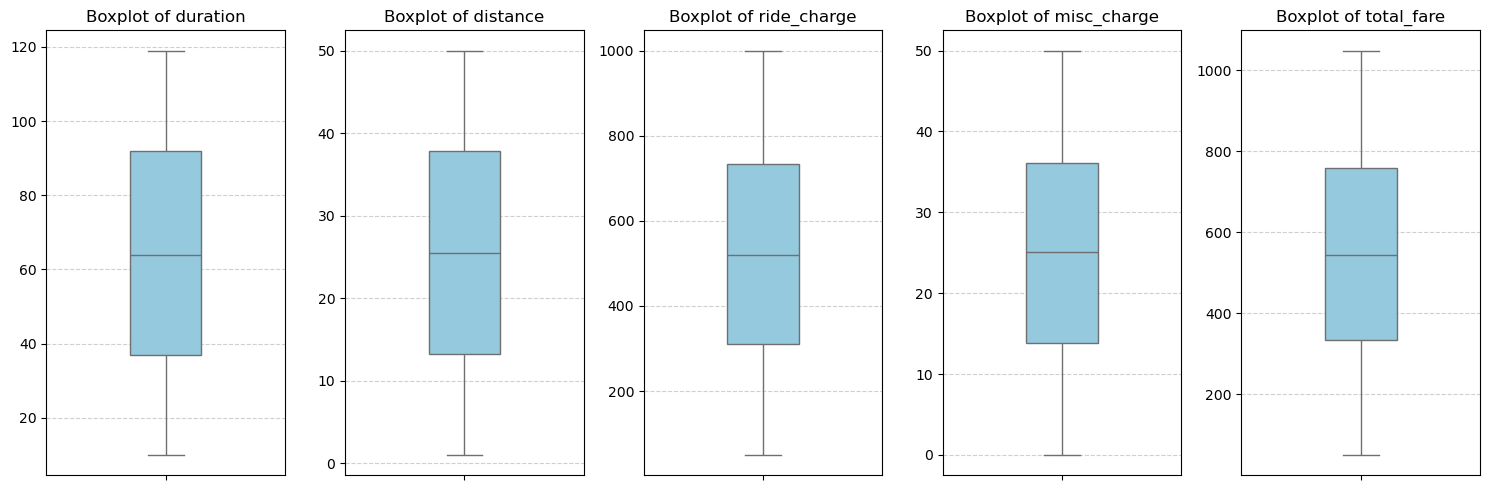

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['duration', 'distance', 'ride_charge', 'misc_charge', 'total_fare']

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [94]:
df.head()

,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,misc_charge,total_fare,payment_method
0,cab economy,2024-07-15,08:30:40,completed,Balagere Harbor,Harohalli Nagar,39,RD3161218751875354,27.21,764.83,31.51,796.34,Amazon Pay
1,auto,2024-07-05,23:36:51,completed,Basavanagudi 3rd Block,Bikasipura 1st Stage,89,RD8171514284594096,34.03,314.83,49.52,364.35,Paytm
2,auto,2024-07-23,11:05:37,cancelled,Babusapalya Cove,Kothaguda Terrace,25,RD9376481122237926,20.24,520.00,25.07,545.07,Paytm
3,cab economy,2024-06-24,08:45:10,completed,Mahadevapura Mews,Kanakapura Arc,89,RD3676889143182765,31.17,484.73,15.84,500.57,QR scan
4,cab economy,2024-07-15,00:26:44,completed,Ganganagar Cove,Basaveshwaranagar Colony,95,RD6639410275948084,27.21,663.50,14.13,677.63,Amazon Pay


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   services        50000 non-null  object        
 1   date            50000 non-null  datetime64[ns]
 2   time            50000 non-null  datetime64[ns]
 3   ride_status     50000 non-null  object        
 4   source          50000 non-null  object        
 5   destination     50000 non-null  object        
 6   duration        50000 non-null  int64         
 7   ride_id         50000 non-null  string        
 8   distance        50000 non-null  float64       
 9   ride_charge     50000 non-null  float64       
 10  misc_charge     50000 non-null  float64       
 11  total_fare      50000 non-null  float64       
 12  payment_method  50000 non-null  object        
dtypes: datetime64[ns](2), float64(4), int64(1), object(5), string(1)
memory usage: 5.0+ MB


In [96]:
df['time'].dtype

dtype('O')